In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
%load_ext autoreload
%autoreload 1
%aimport cowaver.utils
%aimport cowaver.datasets
%aimport cowaver.datamodules
%aimport cowaver.models
%aimport cowaver.modules
%aimport cowaver.modules.architectures
%aimport cowaver.checkpoints
%aimport cowaver.transforms

### Constantes

In [3]:
from pathlib import Path

# Rutas a los datos
compressed_tiny_phones_path = Path("../tiny-phones-500.tar.xz")
compressed_tiny_letter_path = Path("../tiny-letter-30.tar.xz")
compressed_tiny_mswc_path = Path("../tiny-mswc-500.tar.xz")

# Carpeta donde se descomprimirán los datos
data_path = Path("../data")

# Carpeta donde se guardan los checkpoints
checkpoints_path = Path("../checkpoints")

num_layers_in_wav2vec2 = 12

### Funciones utilitarias

### Funciones de graficado

In [4]:
import io
import ipywidgets as widgets
import torchaudio
import torch
import matplotlib.pyplot as plt
import numpy as np
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

def plot_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def plot_image(image, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if image.dim() == 5:
        image = image[0, 0]      # [S,B,C,H,W] -> primera imagen
    elif image.dim() == 4:
        image = image[0]         # [B,C,H,W] -> primera imagen
    elif image.dim() != 3:
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image.detach().cpu()

    ax.imshow(image.clamp(0, 1).permute(1, 2, 0))
    ax.set_title("Imagen")
    # ax.axis("off")

    if should_show:
        plt.show()

def plot_train_history(train_history: TrainHistory, subfig=None):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
        should_show = True
    else:
        ax = subfig.subplots()
        should_show = False
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Entrenamiento")
    ax.plot(epochs, train_history.val_losses, "r", label="Validación")
    ax.set_title("Training vs Validation Loss")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

def plot_logits(logits, classes, subfig=None):
    if subfig is None:
        fig = plt.figure(figsize=(8, 3), layout="constrained")
        subfig = fig.subfigures()
        should_show = True
    else:
        should_show = False

    topk_values, topk_indices = torch.topk(logits.detach().cpu().squeeze(), k=5)
    topk_classes = [classes[i] for i in topk_indices.cpu().numpy()]

    logits, classes = topk_values, topk_classes
    
    values = logits.squeeze().numpy()
    order = np.argsort(values)[::-1]
    sorted_classes  = [classes[i] for i in order]
    sorted_values = values[order]

    ax = subfig.subplots()
    ax.plot(sorted_classes, sorted_values, marker='o')
    ax.set_title("Logits")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    if should_show:
        plt.show()

def plot_test_results(test_results: TestResults | list):
    plt.figure(figsize=(10, 3), layout="constrained")
    if isinstance(test_results, TestResults):
        plt.bar(["top1", "top3", "top5"], [test_results.top1, test_results.top3, test_results.top5])
    else:
        plt.plot(range(len(test_results)), list(map(lambda x: x.top1, test_results)), 'r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top3, test_results)), '--r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top5, test_results)), ':r')
        plt.legend(["top1", "top3", "top5"])
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

def plot_activation(activation, ax=None, vmin=-3, vmax=3):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if activation.dim() == 4:
        activation = activation[0, 0]
    elif activation.dim() == 3:
        activation = activation[0]
    elif activation.dim() != 2:
        raise ValueError(f"Unexpected activation shape: {activation.shape}")

    activation = activation.detach().cpu()

    im = ax.imshow(
        activation.numpy(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_title("Activación")
    ax.set_xlabel("Dimensión")
    ax.set_ylabel("Ventana")
    ax.set_xticks([0, activation.size(1) - 1])
    ax.set_yticks([0, activation.size(0) - 1])

    if should_show:
        plt.colorbar(im, ax=ax)
        plt.show()

    return im
        
def plot_mel(mel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = torch.expm1(mel).clamp_min(0)
    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto"
    )

    ax.set_title("Mel")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Mel bins")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()


def plot_pca(scores: torch.Tensor, labels: list | None):
    """Grafica una proyección PCA bidimensional.

    Parameters
    ----------
    scores: Tensor
        Tensor de forma [B, q], donde B es el número de ejemplos.
        Se grafican las dos primeras componentes.

    labels: list | None
        Lista opcional de etiquetas, una por ejemplo. Si se proporciona,
        debe tener largo B.
    """
    
    scores = scores.detach().cpu()

    if labels is not None and len(labels) != scores.size(0):
        raise ValueError("labels debe tener el mismo largo que scores.")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(scores[:, 0], scores[:, 1])
    if labels is not None:
        for i, label in enumerate(labels):
            plt.text(scores[i, 0].item(), scores[i, 1].item(), label, fontsize=9)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.grid(True)
    plt.show()

## Preparación del entorno

In [5]:
from cowaver.utils import (
    descomprimir_archivo,
    listar_clases,
    construir_vocabulario_caracteres
)

tiny_letter_path = descomprimir_archivo(compressed_tiny_letter_path, data_path)
tiny_phones_path = descomprimir_archivo(compressed_tiny_phones_path, data_path)
tiny_mswc_path = descomprimir_archivo(compressed_tiny_mswc_path, data_path)

letras = listar_clases(tiny_letter_path / "train")
palabras = listar_clases(tiny_phones_path / "train")

print("Letras:", letras)
# print("tiny-mswc-500:", listar_clases(tiny_mswc_path / "train"))

vocabulario = construir_vocabulario_caracteres(datasets=[
    (tiny_letter_path, None),
    (tiny_phones_path, None),
    (tiny_mswc_path, None)]
)
print("Vocabulario:", vocabulario)

Descomprimiendo ../tiny-letter-30.tar.xz en ../data/tiny-letter-30... YA EXISTE
Descomprimiendo ../tiny-phones-500.tar.xz en ../data/tiny-phones-500... YA EXISTE
Descomprimiendo ../tiny-mswc-500.tar.xz en ../data/tiny-mswc-500... YA EXISTE
Letras: ['a', 'b', 'c', 'ch', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'll', 'm', 'n', 'o', 'p', 'q', 'r', 'rr', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'ñ']
Vocabulario: {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, 'ñ': 27}


## Conjuntos de datos

### TinyMel

In [6]:
from cowaver.datamodules import TinyMel
from cowaver.datasets import TinySpeakDataset, ImageMelDataset
from cowaver.transforms import RandomAlign
from cowaver.utils import explorar_datos, extraer_waveform

letters_data = TinyMel(tiny_letter_path, char_to_idx=vocabulario, mel_bins=80)

def explore_tiny_mel(data, batch):
    (image, mel), label, task_id, ctc_chars, ctc_lengths = batch
    fig = plt.figure(figsize=(9, 3), layout="constrained")
    axes = fig.subplot_mosaic([["image", "mel"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_image(image, axes["image"])
    plot_mel(mel, axes["mel"])
    fig.suptitle(data.classes[label.item()])
    plt.show()

    waveform = extraer_waveform(mel[0])
    display(audio_widget(waveform[0]))

    print("task_id =", task_id.item())
    print("ctc_chars =", ctc_chars.item())

explorar_datos(letters_data, explore_tiny_mel)

## CoWaver

In [18]:
from cowaver.modules import (
    CoWaver,
    build_model,
    ARCHITECTURE_REGISTRY,
    DECODER_REGISTRY,
    ADAPTER_REGISTRY,
)
from cowaver.checkpoints import cargar_checkpoint

architecture = 'dual-route'
print("Arquitectura:", architecture)
print("Arquitecturas disponibles:", list(ARCHITECTURE_REGISTRY.keys()))

adapter = 'convolutional'
print("Adapter:", adapter)
print("Adapters disponibles:", list(ADAPTER_REGISTRY.keys()))

decoder = 'recurrent'
print("Decodificador:", decoder)
print("Decodificadores disponibles:", list(DECODER_REGISTRY.keys()))

cowaver = build_model(
    architecture,
    latent_dim=256,
    hidden_size=256,
    mel_bins=80,
    adapter=adapter,
    decoder=decoder,
    ctc_vocab_size=len(vocabulario)+1,
    ctc_weight=0
)

print("Clase base:", CoWaver.__name__)
print("Clase del modelo:", type(cowaver).__name__)


def task_ids_for_model(net, data, batch_size: int, device):
    if getattr(net, "num_tasks", None) is None:
        return None
    return torch.full(
        (batch_size,),
        data.task_id,
        dtype=torch.long,
        device=device,
    )

train_history = cargar_checkpoint(cowaver, folder=checkpoints_path, phase=1)
train_history = cargar_checkpoint(cowaver, folder=checkpoints_path, phase=2)

Arquitectura: dual-route
Arquitecturas disponibles: ['unconditioned', 'dual-route', 'conditioned']
Adapter: convolutional
Adapters disponibles: ['convolutional', 'pointwise']
Decodificador: recurrent
Decodificadores disponibles: ['convolutional', 'recurrent']
Clase base: CoWaver
Clase del modelo: CoWaverDualRoute
Red cowaver_dual_route_lt256_hs256_sl49_mb80_dcrecurrent | fase 1
Epoch 1/30 | train_loss=0.6723 | val_loss=0.7126
Epoch 2/30 | train_loss=0.6386 | val_loss=0.6517
Epoch 3/30 | train_loss=0.5911 | val_loss=0.6159
Epoch 4/30 | train_loss=0.5851 | val_loss=0.6078
Epoch 5/30 | train_loss=0.5690 | val_loss=0.5999
Epoch 6/30 | train_loss=0.5725 | val_loss=0.5973
Epoch 7/30 | train_loss=0.5621 | val_loss=0.5940
Epoch 8/30 | train_loss=0.5540 | val_loss=0.5866
Epoch 9/30 | train_loss=0.5532 | val_loss=0.5906
Epoch 10/30 | train_loss=0.5595 | val_loss=0.5859
Epoch 11/30 | train_loss=0.5547 | val_loss=0.5904
Epoch 12/30 | train_loss=0.5468 | val_loss=0.5873
Epoch 13/30 | train_loss=0.5

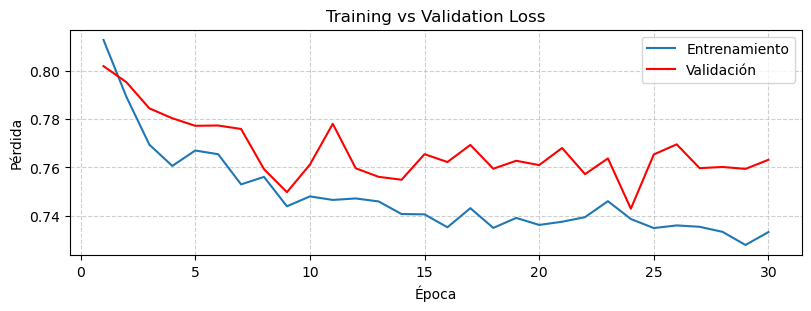

In [19]:
plot_train_history(train_history)

In [22]:
from cowaver.utils import make_image, encontrar_dispositivo
dispositivo = encontrar_dispositivo()

cowaver = cowaver.to(dispositivo)

@widgets.interact(stimulus="e")
def dissect(stimulus: str):
    x = make_image(stimulus)
    with torch.no_grad():
        x = x.to(dispositivo)
        task_ids = torch.full((1,), fill_value=1, dtype=torch.long, device=dispositivo)
        h = cowaver.visual_encoder(x)
        mel, z = cowaver(x, task_ids=task_ids)
        
    fig = plt.figure(figsize=(12, 6), layout="constrained")
    axes = fig.subplot_mosaic([["x", "h", "z"], ["mel", "mel", "mel"]], gridspec_kw={"width_ratios": [1, 2, 2]})
    
    plot_image(x, ax=axes["x"])
    plot_activation(h.cpu(), ax=axes["h"])
    plot_activation(z.cpu(), ax=axes["z"])
    plot_mel(mel.cpu(), ax=axes["mel"])
    
    plt.show()
    
    waveform = extraer_waveform(mel.cpu())
    display(audio_widget(waveform[0]))

Buscando dispositivo... MPS


interactive(children=(Text(value='e', description='stimulus'), Output(outputs=({'output_type': 'display_data',…

In [40]:
from cowaver.utils import make_image, encontrar_dispositivo, distancia_mel

letters_data = TinyMel(tiny_letter_path, char_to_idx=vocabulario, mel_bins=80)

dispositivo = encontrar_dispositivo()
x = make_image("rr")
with torch.no_grad():
    x = x.unsqueeze(0).to(dispositivo)
    cowaver = cowaver.to(dispositivo)
    task_ids = task_ids_for_model(cowaver, letters_data, x.size(0), dispositivo)
    mel, z = cowaver(x, task_ids=task_ids)
    y_hat = mel.squeeze(0).cpu()

results = []
prototypes = letters_data.mel_prototypes()
distancias = distancia_mel(prototypes, y_hat)

for i in range(len(letras)):
    letra = letras[i]
    distancia = distancias[i]
    results.append({"letra": letra, "distancia": distancia.item()})


    
    # results.append({"letra": letra, "distancia": distancia_mel(y, y_hat).item()})

top5 = sorted(results, key=lambda r: r["distancia"])[:5]
for r in top5:
    print(f"{r['letra']} = {r['distancia']:.3f}")

Buscando dispositivo... MPS
d = 0.253
n = 0.256
rr = 0.278
u = 0.281
w = 0.281


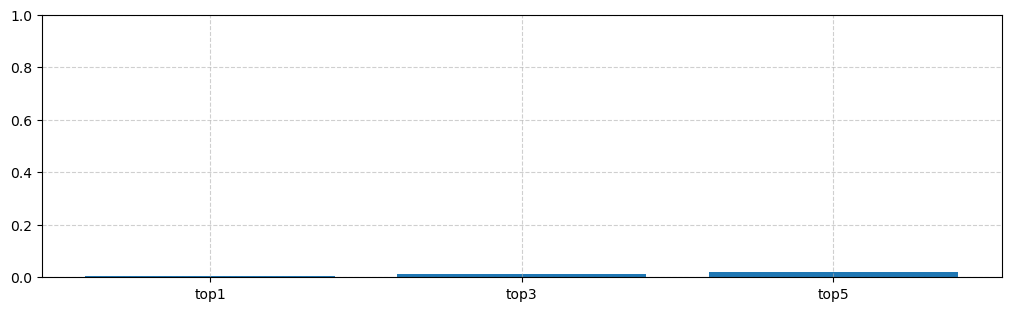

In [17]:
from cowaver.utils import evaluar_red

tiny_phones_data = TinyMel(tiny_mswc_path, char_to_idx=vocabulario, mel_bins=cowaver.mel_bins)
test_results = evaluar_red(cowaver, tiny_phones_data)
plot_test_results(test_results)

Buscando dispositivo... MPS


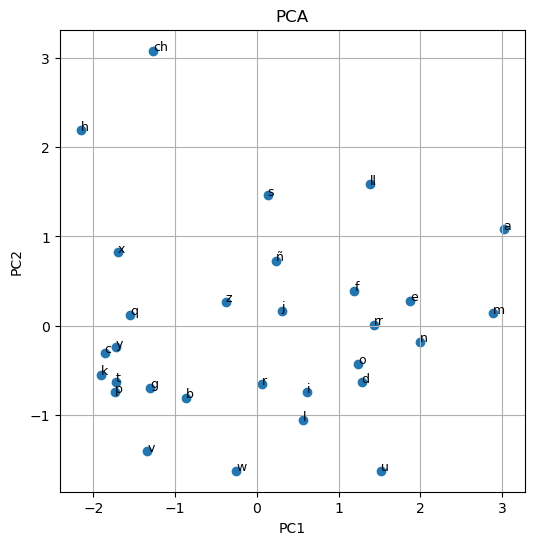

In [37]:
from cowaver.utils import make_image, pca

def pca_analysis(net, stimuli: list, task_id: int | None = None):
    xs = []
    for stimulus in stimuli:
        x = make_image(stimulus)
        xs.append(x)

    dispositivo = encontrar_dispositivo()

    net = net.to(dispositivo)
    
    X = torch.stack(xs, dim=0)
    X = X.to(dispositivo)
    
    with torch.no_grad():
        task_ids = None
        if getattr(net, "num_tasks", None) is not None:
            task_id = 1 if task_id is None else task_id
            task_ids = torch.full(
                (X.size(0),),
                task_id,
                dtype=torch.long,
                device=dispositivo,
            )
        y_hat, z = net(X, task_ids=task_ids)
    
    torch.manual_seed(42)
    X_scores = pca(z.mean(dim=1).cpu())
    plot_pca(X_scores, stimuli)

pca_analysis(cowaver, letras, task_id=letters_data.task_id)

In [ ]:
pca_analysis(cowaver, palabras)